In [3]:
%matplotlib inline

# P300: an index of attention

Using this notebook, we will discuss and learn about the P300, an event-related potential that is associated with attention. 

In [1]:
# Imports
import os, numpy as np,pandas as pd
import warnings
warnings.filterwarnings('ignore')
from eegnb import generate_save_fn
from eegnb.devices.eeg import EEG
from eegnb.experiments.visual_p300 import p300_2 as p300
from collections import OrderedDict
import seaborn as sns
from matplotlib import pyplot as plt

# MNE functions
from mne import Epochs,find_events
from mne.decoding import Vectorizer

# EEG-Notebooks functions
from eegnb.analysis.utils2 import load_data,plot_conditions, check_report
from eegnb.datasets import fetch_dataset

Same as with the N170 dataset, we'll be doing an example of an experiment that tests the (visual) P300. 

### Experiment set-up

In [2]:
# Here we can change the variables that we use for measuring experiments!

board_name = "muse2_bfn" # this can stay the same
experiment = "visual-P300" # this changes depending on the experiment, for the purposes of this notebook it can stay the same
subject_id = 99 # change this each time you have a new participant
session_nb = 99 # change this each time you have a new run
record_duration = 30 # in seconds; this changes how long each session is

In [3]:
# Start EEG device
eeg_device = EEG(device=board_name, serial_num='Muse-9BF6') # make sure to change serial_num into the right Muse you're using

# Create save file name
save_fn = generate_save_fn(board_name, experiment, subject_id, session_nb)
print(save_fn)

C:\Users\vanes\.eegnb\data\visual-P300\local\muse2_bfn\subject0099\session099\recording_2026-05-13-17.54.19.csv


As with before, make sure that the save path is in the place that you want it to be!

### Run experiment

When looking at the experiment, try to count the number of cats that show up on the screen.

In [4]:
check_report(eeg_device)



Running signal quality check...
Accepting threshold stdev between: 1 - 18
running check (up to) 60 times, with 5-second windows
will stop after 2 good check results in a row



1/60

Signal quality:
   Fp1: x  (std:  52.7)
   Fp2: x  (std: 117.3)
  TP10: x  (std: 454.6)
   TP9: x  (std:  79.0)
Bad channels: Fp1, Fp2, TP10, TP9



2/60

Signal quality:
   Fp1: x  (std: 145.9)
   Fp2: x  (std: 368.6)
  TP10: x  (std: 624.2)
   TP9: x  (std: 645.3)
Bad channels: Fp1, Fp2, TP10, TP9



3/60

Signal quality:
   Fp1: x  (std: 402.6)
   Fp2: x  (std: 430.6)
  TP10: x  (std: 447.6)
   TP9: x  (std: 322.0)
Bad channels: Fp1, Fp2, TP10, TP9



4/60

Signal quality:
   Fp1: x  (std: 507.2)
   Fp2: x  (std: 396.0)
  TP10: x  (std: 598.3)
   TP9: x  (std: 558.1)
Bad channels: Fp1, Fp2, TP10, TP9



5/60

Signal quality:
   Fp1: x  (std: 471.0)
   Fp2: x  (std: 321.5)
  TP10: x  (std: 500.4)
   TP9: x  (std: 617.7)
Bad channels: Fp1, Fp2, TP10, TP9


Looks like you still have 4 bad channels after 


Checks will resume in 5 seconds...Press 'c' (and ENTER key) if you want to stop adjusting for better quality.
 c



Stopping signal quality checks!


In [5]:
p300.present(duration=record_duration, eeg=eeg_device, save_fn=save_fn, ver=3) # 1 is for cats and dogs, 2 is for letters and symbols, 3 is for red and blue circles

402.3380 	WARNING 	User requested fullscreen with size [1600  900], but screen is actually [1280, 800]. Using actual size
403.9359 	WARNING 	User requested fullscreen with size [1600  900], but screen is actually [1280, 800]. Using actual size


As with before, make sure that you confirm that your files are saved in the right place before we do the visualization. 

### Visualization

As a reminder, the P300 looks like this (see P3 below):

![P300](p300.png)

In [6]:
eegnb_data_path = os.path.join(os.path.expanduser('~/'),'.eegnb', 'data')    

# to load data from a specific subject and session:
subject = 99
session = 99
# make sure that these numbers are correct, or it will run from the last time you used 'subject' and 'session', 
# including from above!

raw = load_data(subject,session,
                experiment='visual-P300', site='local', device_name='muse2_bfn',
                data_dir = eegnb_data_path)

['TP9', 'Fp1', 'Fp2', 'TP10', 'stim']
['TP9', 'Fp1', 'Fp2', 'TP10', 'stim']
Creating RawArray with float64 data, n_channels=5, n_times=35092
    Range : 0 ... 35091 =      0.000 ...   137.074 secs
Ready.


As with before, we'll be doing some initial filtering of the data to capture the range of the data that we're the most interested in looking at. We'll also be cutting out trials based on some artifacts that we expect to emerge because of people blinking their eyes. Those tend to make much larger fluctuations in the EEG signal than what we're interested in, so we can do this by cutting out any epoch that has a fluctuation larger than a certain threshold.

In [8]:
raw.filter(1,20, method='iir')
# raw.plot_psd(fmin=1, fmax=30); # visualize power spectrum after filtering

# Create an array containing the timestamps and type of each stimulus (i.e. face or house)
events = find_events(raw)
event_id = {'Non-Target': 1, 'Target': 2}

# Create an MNE Epochs object representing all the epochs around stimulus presentation
epochs = Epochs(raw, events=events, event_id=event_id, 
                tmin=-0.1, tmax=0.8, baseline=None,
                reject={'eeg': 75e-6}, preload=True, 
                verbose=False, picks=[0,1,2,3])
print('sample drop %: ', (1 - len(epochs.events)/len(events)) * 100)
epochs

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 20 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 20.00 Hz: -6.02, -6.02 dB

38 events found
Event IDs: [1 2]
sample drop %:  0.0


Number of events,38
Events,Non-Target: 33Target: 5
Time range,-0.102 – 0.801 sec
Baseline,off


We're looking for that sample drop % to be as low as possible. If yours is higher than 15%, check the raw number of trials that have come out. It could be that the original recording was a bit noisy, and that's okay. You should run enough trials to have at least 50 remaining for the Target condition.

Using data from preloaded Raw for 38 events and 232 original time points ...
0 bad epochs dropped


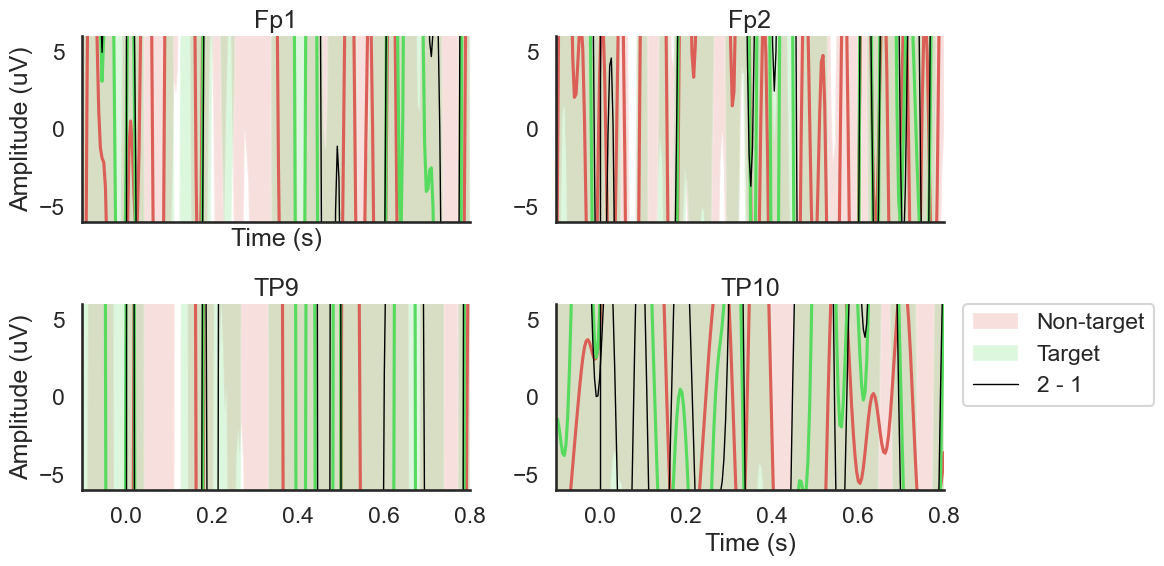

In [9]:
conditions = OrderedDict()
conditions['Non-target'] = [1]
conditions['Target'] = [2]

fig, ax = plot_conditions(epochs, conditions=conditions, 
                          ci=97.5, n_boot=1000, title='',
                          diff_waveform=(1, 2),
                          channel_order=[1, 0, 2, 3])

Use the below code to subsequently save your plot. Don't forget to change the name of the image file accordingly! Consider saving with the name of the person whose data this is, or anything else that will indicate to you whose file it is. 

In [ ]:
fig.savefig('p300_myplot.png')